# **Fraud Detection**

### **Problem Statement:-**

Financial fraud is a major challenge for banks and payment platforms. Fraudulent transactions cause significant financial losses and undermine customer trust. Traditional rule-based systems often fail to detect sophisticated fraud patterns, making machine learning a powerful tool for identifying anomalies in transaction data.

The objective of this project is to build a **machine learning-based fraud detection system** capable of identifying suspicious transactions in credit card payment data.

The system will analyze transaction features and classify each transaction as either:

- **Legitimate Transaction (Class = 0)**
- **Fraudulent Transaction (Class = 1)**

One major challenge in this problem is the **extreme class imbalance** in the dataset. Fraudulent transactions represent only a very small fraction of all transactions, making it difficult for standard machine learning models to detect them effectively.

Therefore, the project focuses on:

- Handling **highly imbalanced data**
- Using appropriate **evaluation metrics** such as Precision, Recall, F1-score, and PR-AUC
- Building models capable of identifying **rare fraudulent patterns**

The final goal is to develop a **robust fraud detection model** that can accurately identify fraudulent transactions while minimizing false alarms.

### **Importing Dependencies**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### **Loading Dataset & Dataset Description**

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Datasets/credit_data.csv")
df.shape

(284807, 31)

In [ ]:
df.sample(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
247228,153509.0,1.433616,-1.745711,-1.520750,-0.058329,-0.950516,-0.794503,0.117139,-0.338633,-0.618978,...,0.223604,0.495259,-0.286899,0.109874,0.050707,-0.082405,-0.056561,-0.000809,360.00,0
156086,107247.0,-0.434808,0.687426,0.589999,-0.763537,1.766174,-0.598813,1.126436,-0.513746,1.064002,...,0.071809,0.632176,-0.581353,-1.070925,0.542686,-0.101501,-0.107610,-0.117968,1.99,0
8097,11019.0,1.447657,-0.662266,-0.816183,-1.622779,1.395808,3.340542,-1.323398,0.741863,0.461249,...,-0.093087,-0.266850,-0.012382,0.951074,0.499571,-0.306994,-0.009118,0.009481,15.95,0
251820,155513.0,-2.972780,-2.403812,1.064995,-0.545382,2.368264,0.417074,-0.677048,0.661271,0.285535,...,0.184630,1.138684,1.511208,-1.615795,0.164760,0.849735,0.419242,0.110403,50.00,0
149280,90929.0,-0.281948,1.241406,-0.221163,-0.457810,1.387643,-0.008391,0.799084,0.017627,1.086769,...,-0.114923,0.233522,-0.339241,0.070718,-0.141151,0.520985,0.346959,0.248628,1.69,0


#### **Dataset Overview**

The dataset used in this project contains credit card transactions made by European cardholders. It includes both legitimate and fraudulent transactions recorded over a two-day period.

Key characteristics of the dataset:

- **Total Transactions:** 284,807
- **Fraudulent Transactions:** 492
- **Legitimate Transactions:** 284,315
- **Fraud Percentage:** ~0.17%

Due to confidentiality issues, most features have been transformed using **Principal Component Analysis (PCA)**. As a result, the original feature names and meanings are not available. These transformed features are labeled as:

- **V1, V2, V3, ... , V28**

Additional features include:

- **Time** – Seconds elapsed between this transaction and the first transaction in the dataset.
- **Amount** – Transaction amount.
- **Class** – Target variable indicating fraud (1) or normal transaction (0).

Because the dataset is **extremely imbalanced**, special techniques will be required to properly train and evaluate machine learning models.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [ ]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


#### **Initial Data Inspection – Key Inferences**

After loading and inspecting the dataset, the following observations were made:

1. **No Missing Values**
   
   The dataset does not contain any missing or null values, which simplifies the preprocessing stage.

2. **All Features Are Numerical**
   
   All input variables are numerical, which allows machine learning models to be applied directly without categorical encoding.

3. **Highly Imbalanced Dataset**
   
   Fraudulent transactions represent only about **0.17% of the dataset**, while normal transactions account for **99.83%**. This extreme imbalance makes the problem challenging and requires careful model evaluation.

4. **Presence of PCA-Transformed Features**
   
   Most features (V1–V28) are the result of PCA transformation for privacy protection. This means that feature interpretability is limited, but the features can still be used effectively for modeling.

5. **Transaction Amount Has Large Variance**
   
   The transaction amount feature has a wide range of values, which may require scaling during preprocessing.

These observations highlight the importance of using appropriate techniques to handle **class imbalance and model evaluation**, which will be addressed in the subsequent stages of the project.

In [ ]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


In [ ]:
df['Class'].value_counts(normalize=True)

,proportion
Class,
0,0.998273
1,0.001727


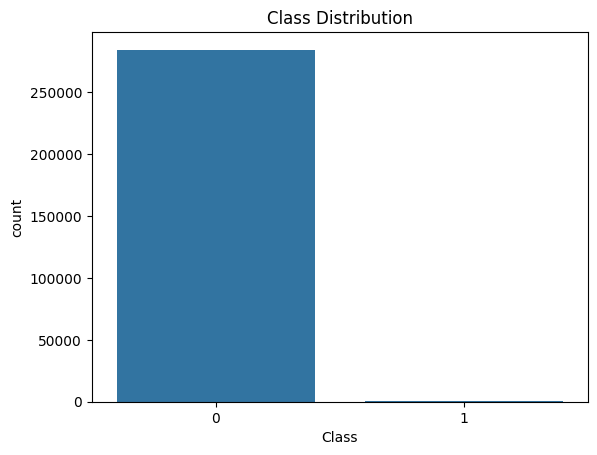

In [ ]:
sns.countplot(x='Class', data=df)
plt.title("Class Distribution")
plt.show()

In [ ]:
fraud_ratio = df['Class'].value_counts()[1] / len(df)
print(f"Fraud Ratio: {fraud_ratio:.4f}")

Fraud Ratio: 0.0017


The dataset contains 284,807 transactions with 492 fraudulent cases (0.17%). This extreme class imbalance makes fraud detection challenging and requires specialized evaluation metrics such as Precision, Recall, and PR-AUC instead of accuracy.

### **Exploratory Data Analysis (EDA)**

Exploratory Data Analysis helps in understanding the structure and patterns within the dataset before building machine learning models.

In this stage, we analyze:

- Distribution of fraudulent vs normal transactions
- Transaction amount patterns
- Transaction time patterns
- Correlations between features
- Potential outliers in transaction data

These insights help identify important characteristics of fraudulent transactions and guide the model development process.

**1.) Class Distribution Visualization**

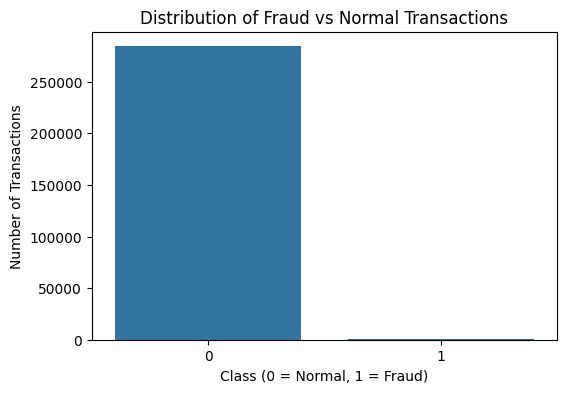

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title("Distribution of Fraud vs Normal Transactions")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Number of Transactions")
plt.show()

The dataset is extremely imbalanced. The majority of transactions are legitimate (Class 0), while fraudulent transactions (Class 1) represent only a very small fraction of the dataset.

This imbalance makes the problem challenging because a model predicting all transactions as normal could still achieve very high accuracy. Therefore, metrics such as **Precision, Recall, F1-score, and PR-AUC** will be more appropriate for evaluating model performance.

**2.) Transaction Amount Distribution**

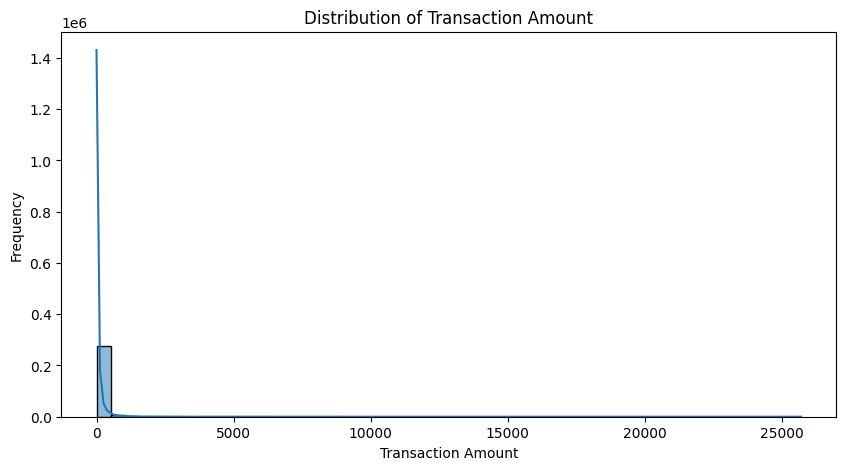

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df['Amount'], bins=50, kde=True)
plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.show()

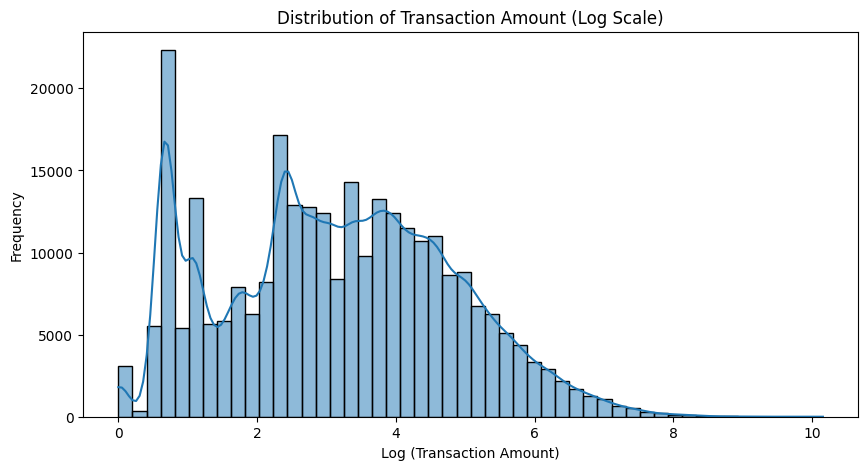

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(np.log1p(df['Amount']), bins=50, kde=True)
plt.title("Distribution of Transaction Amount (Log Scale)")
plt.xlabel("Log (Transaction Amount)")
plt.ylabel("Frequency")
plt.show()

Transaction amounts show a highly skewed distribution where most transactions are of small value and very large transactions occur rarely.
A log transformation is applied to better visualize the distribution of transaction amounts.

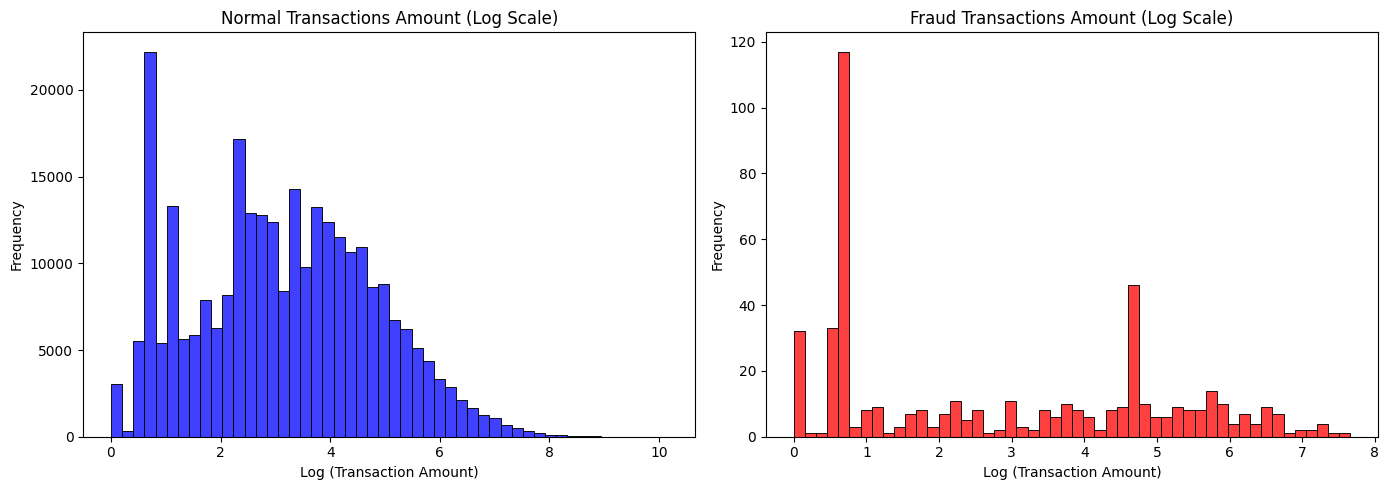

In [ ]:
plt.figure(figsize=(14,5))

# Normal transactions
plt.subplot(1,2,1)
sns.histplot(np.log1p(df[df['Class']==0]['Amount']), bins=50, color='blue')
plt.title("Normal Transactions Amount (Log Scale)")
plt.xlabel("Log (Transaction Amount)")
plt.ylabel("Frequency")

# Fraud transactions
plt.subplot(1,2,2)
sns.histplot(np.log1p(df[df['Class']==1]['Amount']), bins=50, color='red')
plt.title("Fraud Transactions Amount (Log Scale)")
plt.xlabel("Log (Transaction Amount)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

The distribution of transaction amounts shows that most transactions occur at lower amounts, while high-value transactions are relatively rare.

Fraudulent transactions appear across a range of amounts, indicating that fraud does not necessarily occur only in high-value transactions. This suggests that transaction amount alone is not sufficient to detect fraud, and multiple features must be considered together.

**3.) Transaction Time Analysis**

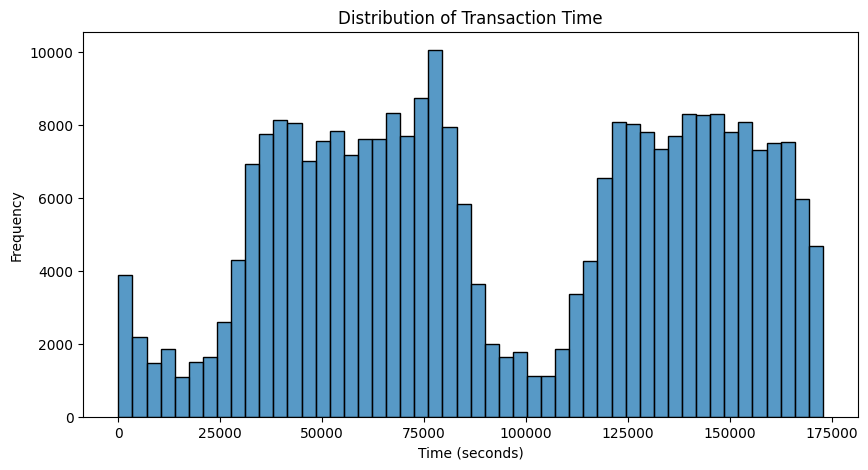

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df['Time'], bins=50)
plt.title("Distribution of Transaction Time")
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency")
plt.show()

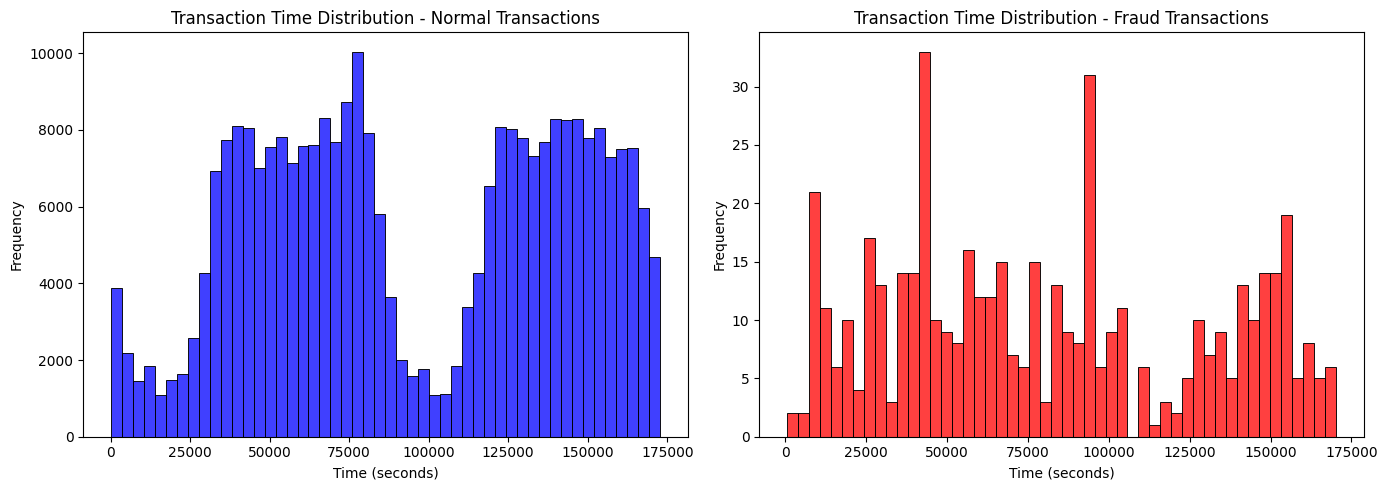

In [ ]:
plt.figure(figsize=(14,5))

# Normal transactions
plt.subplot(1,2,1)
sns.histplot(df[df['Class']==0]['Time'], bins=50, color='blue')
plt.title("Transaction Time Distribution - Normal Transactions")
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency")

# Fraud transactions
plt.subplot(1,2,2)
sns.histplot(df[df['Class']==1]['Time'], bins=50, color='red')
plt.title("Transaction Time Distribution - Fraud Transactions")
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

The transaction time distribution shows activity across the entire observation period. Fraudulent transactions are spread throughout the dataset rather than being concentrated in a specific time window.

This suggests that fraud patterns are not strongly dependent on transaction time alone.

**4.) Correlation Heatmap**

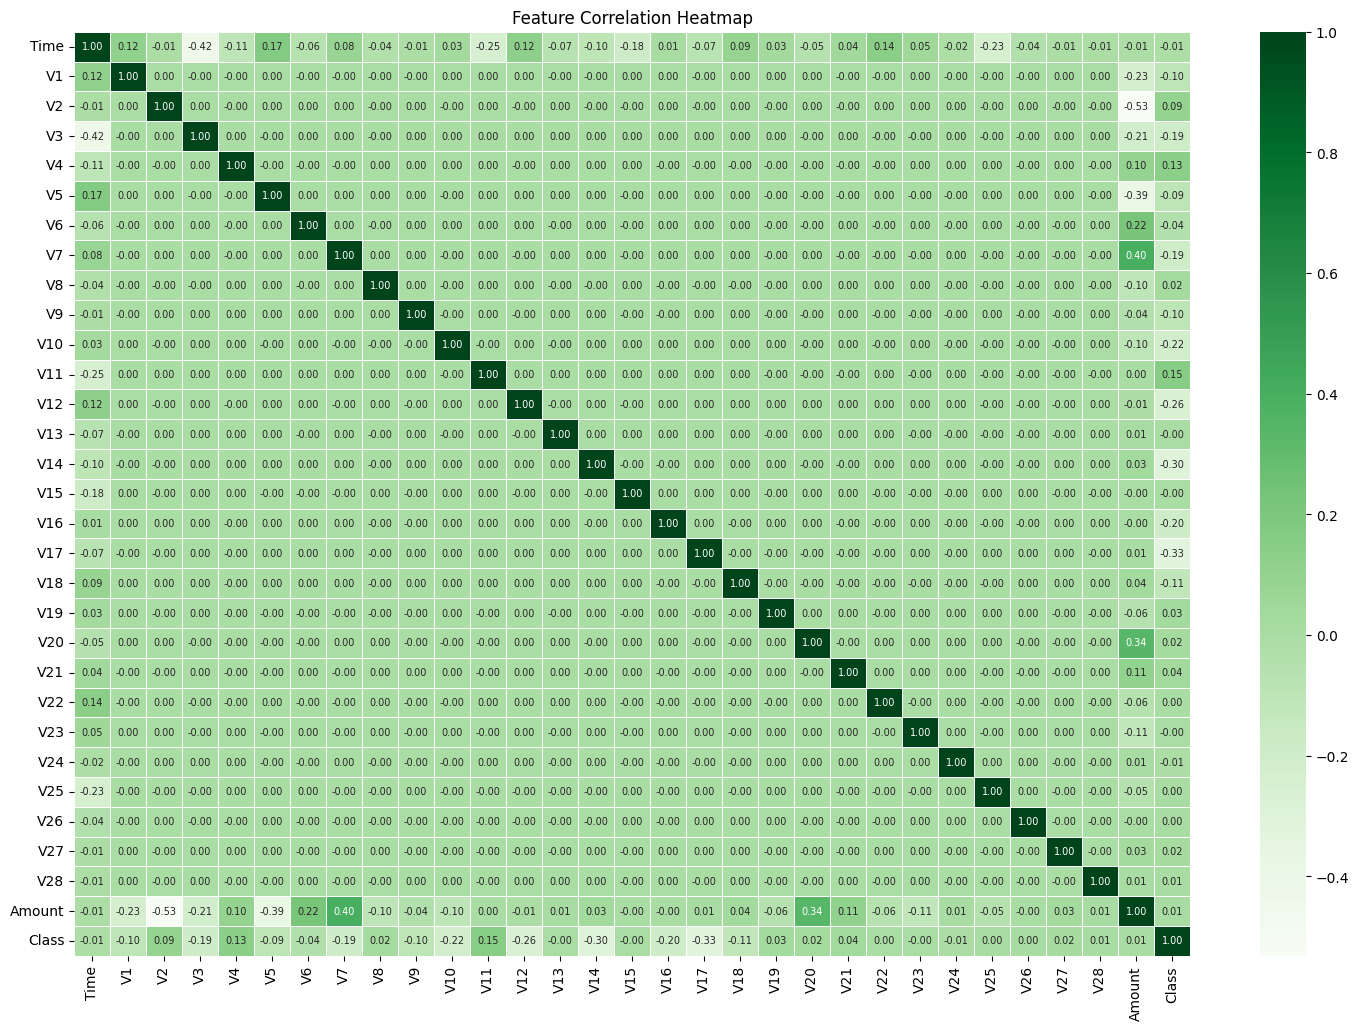

In [ ]:
plt.figure(figsize=(18,12))
corr = df.corr()
sns.heatmap( corr, cmap='Greens', annot=True, fmt=".2f", linewidths=0.5, annot_kws={"size":7})
plt.title("Feature Correlation Heatmap")
plt.show()

The correlation heatmap shows the relationships between features in the dataset.

Since most features have been transformed using PCA, strong correlations between features are limited. This transformation helps remove multicollinearity and compress the original feature space into principal components.

However, the transformed features can still capture important patterns useful for detecting fraudulent behavior.

**5.) Fraud Feature Distribution**

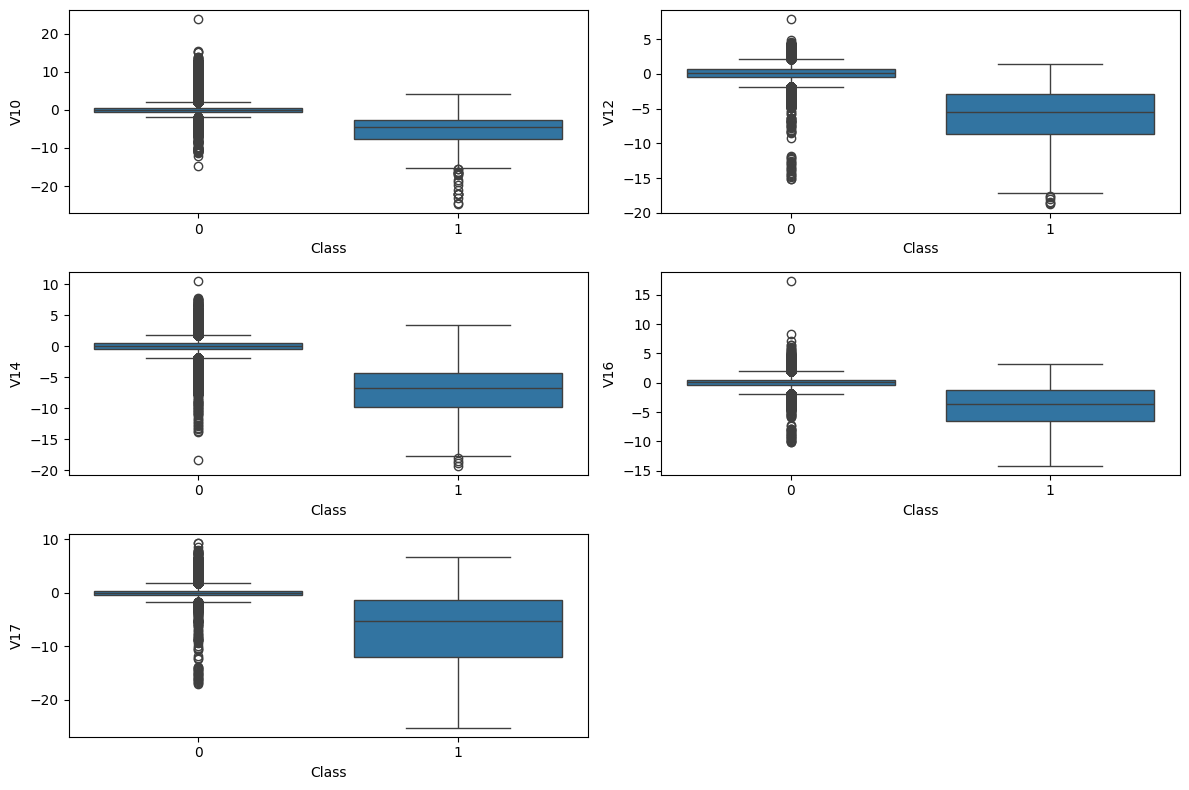

In [ ]:
features = ['V10','V12','V14','V16','V17']
plt.figure(figsize=(12,8))

for i, feature in enumerate(features, 1):
    plt.subplot(3,2,i)
    sns.boxplot(x='Class', y=feature, data=df)

plt.tight_layout()
plt.show()

The boxplots show noticeable differences in the distributions of certain PCA features between fraudulent and normal transactions.

Some features exhibit distinct value ranges for fraud cases compared to legitimate transactions, indicating that these features may play an important role in distinguishing fraudulent behavior.

Machine learning models can leverage these patterns across multiple features to effectively detect fraud.

### **Data Preprocessing & Overview**

**1.) Separate Features and Target**

In [ ]:
X = df.drop(columns='Class', axis=1)
Y = df['Class']

**2.) Scale the Amount Feature**

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X['Amount'] = scaler.fit_transform(X[['Amount']])

**3.) Handle Time Feature**

In [ ]:
"""
The Time column represents seconds since first transaction.
It doesn't represent real-world time (hour/day), so it usually does not add strong predictive value.
For simplicity we drop it.
"""
X = X.drop('Time', axis=1)

**4.) Train-Test Split**

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=42)

In [ ]:
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (227845, 29)
Test set shape: (56962, 29)


**5.) Verify Class Distribution**

In [ ]:
print("Training class distribution:")
print(Y_train.value_counts(normalize=True))

print("\nTest class distribution:")
print(Y_test.value_counts(normalize=True))

Training class distribution:
Class
0    0.998271
1    0.001729
Name: proportion, dtype: float64

Test class distribution:
Class
0    0.99828
1    0.00172
Name: proportion, dtype: float64


#### **Data Preprocessing**

Before training machine learning models, the dataset was preprocessed to ensure consistent feature scaling and proper dataset splitting.

The following preprocessing steps were performed:

1. **Feature–Target Separation**
   The target variable `Class` was separated from the feature set.

2. **Feature Scaling**
   The `Amount` feature was standardized using `StandardScaler` because it had a much larger numeric range compared to other features.

3. **Handling Time Feature**
   The `Time` feature was removed since it represents the elapsed time between transactions and does not directly correspond to meaningful real-world time information.

4. **Stratified Train-Test Split**
   The dataset was split into training and testing sets using stratified sampling to maintain the same fraud ratio in both sets.

This preprocessing step ensures that the machine learning models are trained on properly scaled data while preserving the original class imbalance structure of the dataset.

### **Baseline Model - Logistic Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc

**1.) Logistic Model Training**

In [ ]:
model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train, Y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
Y_prob = model.predict_proba(X_test)[:,1]
Y_pred = model.predict(X_test)

**2.) Confusion Matrix**

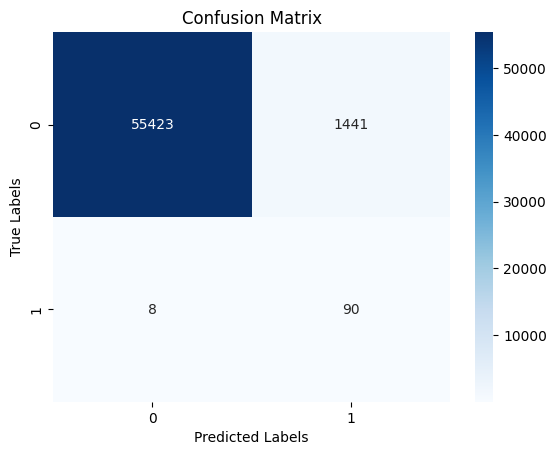

In [ ]:
conf_mat = confusion_matrix(Y_test, Y_pred)
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

**3.) Classification report and ROC-AUC**

In [ ]:
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



In [ ]:
roc_auc = roc_auc_score(Y_test, Y_prob)
print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.9714465520310545


**4.) Precision, Recall and PR-curve**

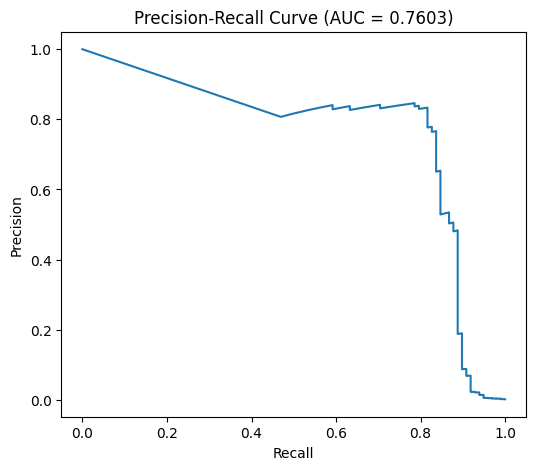

In [ ]:
precision, recall, thresholds = precision_recall_curve(Y_test, Y_prob)
pr_auc = auc(recall, precision)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (AUC = {pr_auc:.4f})")
plt.show()

#### Baseline Model – Logistic Regression

A Logistic Regression model was trained as the baseline classifier for fraud detection.
Because the dataset is highly imbalanced, the model was trained using `class_weight='balanced'` to give more importance to the minority fraud class.

The model was evaluated using metrics appropriate for imbalanced classification problems, including:

- Precision
- Recall
- F1-score
- ROC-AUC
- Precision–Recall AUC

These metrics provide a better understanding of how well the model detects fraudulent transactions compared to traditional accuracy.

The baseline model performance will serve as a reference point for evaluating more advanced models such as Random Forest and XGBoost.

### **Random Tree Model**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc

**1.) Random Forest Model Training**

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, Y_train)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [ ]:
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:,1]

**2.) Confusion Matrix**

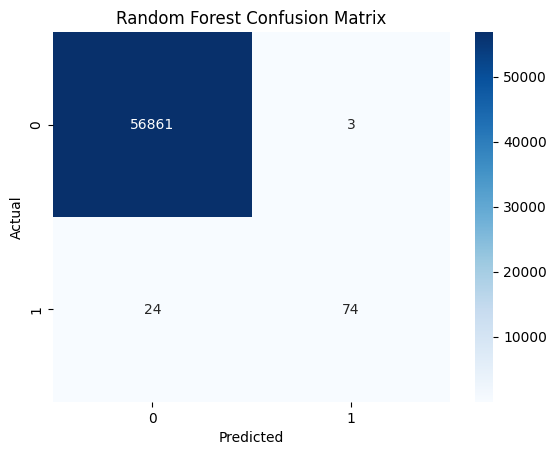

In [ ]:
conf_mat = confusion_matrix(Y_test, rf_pred)
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**3.) Classification report and ROC-AUC**

In [ ]:
print(classification_report(Y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.76      0.85        98

    accuracy                           1.00     56962
   macro avg       0.98      0.88      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [ ]:
rf_auc = roc_auc_score(Y_test, rf_prob)
print("Random Forest ROC-AUC:", rf_auc)

Random Forest ROC-AUC: 0.9580130501131234


### **XGBoost Classifier**

In [ ]:
from xgboost import XGBClassifier

**1.) XGBoost Classifier Model Training**

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=(len(Y_train[Y_train==0]) / len(Y_train[Y_train==1])),
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, Y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:,1]

**2.) Confusion Matrix**

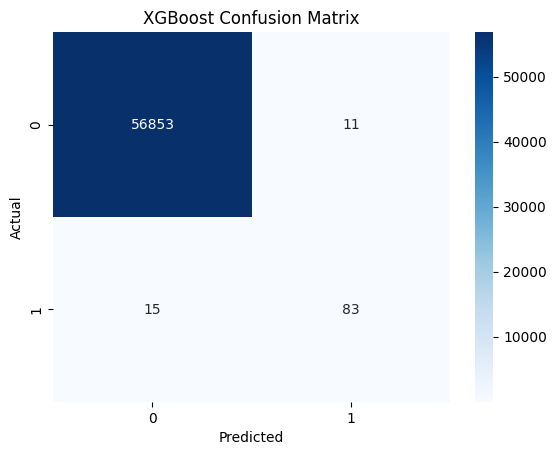

In [ ]:
conf_mat = confusion_matrix(Y_test, xgb_pred)
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**3.) Classification report and ROC-AUC**

In [ ]:
print(classification_report(Y_test, xgb_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.88      0.85      0.86        98

    accuracy                           1.00     56962
   macro avg       0.94      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962



In [ ]:
xgb_auc = roc_auc_score(Y_test, xgb_prob)
print("XGBoost ROC-AUC:", xgb_auc)

XGBoost ROC-AUC: 0.9691087148140067


### **Model Comparison Table**

In [ ]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "ROC-AUC": [roc_auc, rf_auc, xgb_auc]
})
results

,Model,ROC-AUC
0,Logistic Regression,0.971447
1,Random Forest,0.958013
2,XGBoost,0.969109


#### **Model Comparison**

Three machine learning models were evaluated for the fraud detection task:

- Logistic Regression (baseline model)
- Random Forest
- XGBoost

The models were compared using **ROC-AUC score**, which measures the ability of a classifier to distinguish between fraudulent and legitimate transactions.

| Model | ROC-AUC |
|------|------|
| Logistic Regression | 0.971 |
| Random Forest | 0.958 |
| XGBoost | 0.969 |

#### **Observations**

1. **Logistic Regression achieved the highest ROC-AUC score**, indicating strong discrimination between fraudulent and legitimate transactions.

2. **XGBoost also performed competitively**, slightly below Logistic Regression but still showing strong predictive capability.

3. **Random Forest performed slightly worse**, which may be due to the lack of hyperparameter tuning or the nature of PCA-transformed features in the dataset.

#### **Interpretation**

The dataset features are already transformed using **Principal Component Analysis (PCA)**, which often produces linearly separable features. Because of this, simpler models like Logistic Regression can perform very well.

#### **Conclusion**

Logistic Regression currently performs the best among the evaluated models. However, XGBoost remains a strong candidate for further optimization due to its ability to capture complex patterns and handle class imbalance effectively.

Further improvements will be explored in the next steps using techniques such as **class imbalance handling and threshold optimization**.

### **Handling Class Imbalance**

In [ ]:
!pip install imbalanced-learn

**1.) SMOTE Oversampling**

In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
smote = SMOTE(random_state=42)
X_train_smote, Y_train_smote = smote.fit_resample(X_train, Y_train)
print(Y_train_smote.value_counts())

Class
0    227451
1    227451
Name: count, dtype: int64


In [ ]:
xgb_smote = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)
xgb_smote.fit(X_train_smote, Y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
smote_pred = xgb_smote.predict(X_test)
smote_prob = xgb_smote.predict_proba(X_test)[:,1]

In [ ]:
print(classification_report(Y_test, smote_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.56      0.87      0.68        98

    accuracy                           1.00     56962
   macro avg       0.78      0.93      0.84     56962
weighted avg       1.00      1.00      1.00     56962



**2.) Random Undersampling**

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

In [ ]:
undersampler = RandomUnderSampler(random_state=42)
X_train_under, Y_train_under = undersampler.fit_resample(X_train, Y_train)
print(Y_train_under.value_counts())

Class
0    394
1    394
Name: count, dtype: int64


In [ ]:
xgb_under = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)
xgb_under.fit(X_train_under, Y_train_under)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
under_pred = xgb_under.predict(X_test)
under_prob = xgb_under.predict_proba(X_test)[:,1]

In [ ]:
print(classification_report(Y_test, under_pred))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98     56864
           1       0.03      0.92      0.07        98

    accuracy                           0.96     56962
   macro avg       0.52      0.94      0.52     56962
weighted avg       1.00      0.96      0.98     56962



**3.) Compare Approaches**

In [ ]:
results = pd.DataFrame({
    "Method": ["Original Data", "SMOTE", "Undersampling"],
    "ROC-AUC": [
        roc_auc_score(Y_test, xgb_prob),
        roc_auc_score(Y_test, smote_prob),
        roc_auc_score(Y_test, under_prob)
    ]
})
results

,Method,ROC-AUC
0,Original Data,0.969109
1,SMOTE,0.977994
2,Undersampling,0.973110


#### **Handling Class Imbalance**

The dataset contains an extreme class imbalance where fraudulent transactions represent only a small fraction of all transactions. Such imbalance can cause machine learning models to become biased toward the majority class.

To address this issue, two techniques were explored:


#### **SMOTE (Synthetic Minority Oversampling Technique)**

SMOTE generates synthetic examples of the minority class by interpolating between existing fraud samples. This helps the model learn fraud patterns more effectively without simply duplicating existing records.


#### **Random Undersampling**

Random undersampling balances the dataset by reducing the number of majority class samples. While this helps the model focus on fraud detection, it may also lead to loss of useful information from legitimate transactions.

The performance of models trained using these techniques was compared with the model trained on the original dataset to determine the most effective approach for fraud detection.


| Method | ROC-AUC |
|------|------|
| Original Data | 0.969 |
| SMOTE | 0.978 |
| Undersampling | 0.973 |



#### **Observations**

- SMOTE achieved the highest ROC-AUC score, indicating improved ability to distinguish fraudulent transactions.
- Undersampling also improved performance but may lose useful information by removing legitimate transactions.
- Training on the original dataset already produced strong performance due to the informative PCA features.


#### **Conclusion**

SMOTE provided the best performance among the evaluated techniques. Therefore, the final fraud detection model will be trained using **XGBoost with SMOTE-balanced training data**.

### **Threshold Optimization**

In [ ]:
Y_prob = xgb_smote.predict_proba(X_test)[:,1]

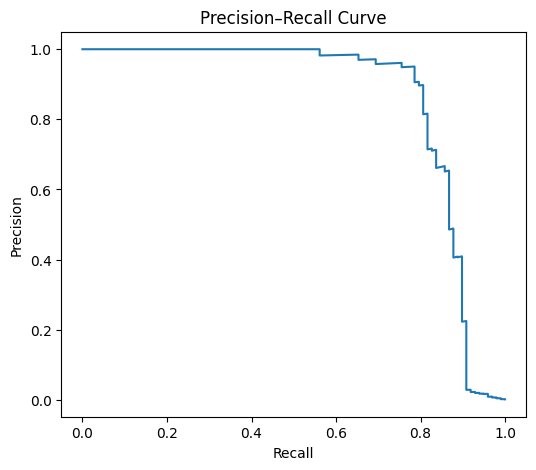

In [ ]:
from sklearn.metrics import precision_recall_curve
precision, recall, thresholds = precision_recall_curve(Y_test, Y_prob)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.show()

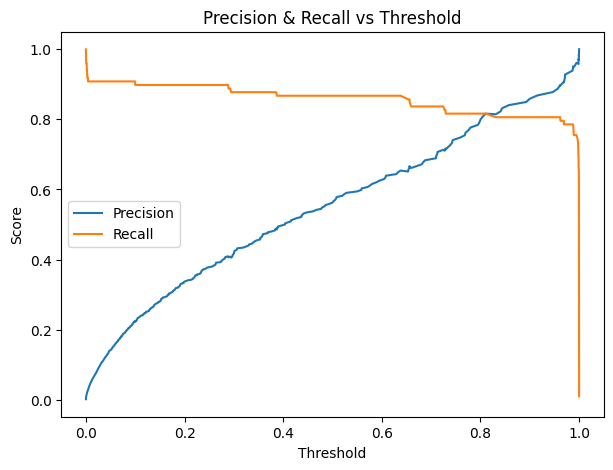

In [ ]:
plt.figure(figsize=(7,5))
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision & Recall vs Threshold")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
thresholds = [0.3, 0.5, 0.78, 0.82]

for t in thresholds:
    Y_pred_t = (Y_prob >= t).astype(int)
    print(f"\nThreshold: {t}")
    print(f"Precision: {precision_score(Y_test, Y_pred_t)}")
    print(f"Recall: {recall_score(Y_test, Y_pred_t)}")
    print(f"F1-score: {f1_score(Y_test, Y_pred_t)}")


Threshold: 0.3
Precision: 0.4195121951219512
Recall: 0.8775510204081632
F1-score: 0.5676567656765676

Threshold: 0.5
Precision: 0.5629139072847682
Recall: 0.8673469387755102
F1-score: 0.6827309236947792

Threshold: 0.78
Precision: 0.7843137254901961
Recall: 0.8163265306122449
F1-score: 0.8

Threshold: 0.82
Precision: 0.8144329896907216
Recall: 0.8061224489795918
F1-score: 0.8102564102564103


#### **Threshold Optimization**

Different classification thresholds were evaluated to determine the best trade-off between fraud detection (recall) and false fraud alerts (precision).

| Threshold | Precision | Recall | F1-score |
|---|---|---|---|
| 0.30 | 0.42 | 0.88 | 0.57 |
| 0.50 | 0.56 | 0.87 | 0.68 |
| 0.78 | 0.78 | 0.82 | 0.80 |
| 0.82 | 0.81 | 0.81 | 0.81 |

Lower thresholds increased recall but produced many false fraud alerts. Higher thresholds improved precision while slightly reducing recall.

A threshold of **0.82** achieved the highest F1-score and provided the best balance between precision and recall. Therefore, this threshold was selected for the final fraud detection system.

### **Business Cost Simulation**

In [ ]:
cost_false_negative = 1000   # missed fraud
cost_false_positive = 10     # investigate normal transaction

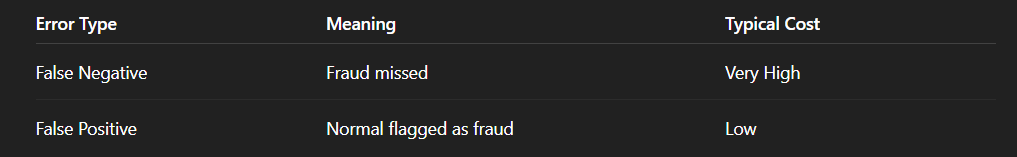

In [ ]:
from sklearn.metrics import confusion_matrix

Y_pred_opt = xgb_smote.predict(X_test)
conf_mat = confusion_matrix(Y_test, Y_pred_opt)
TN, FP, FN, TP = conf_mat.ravel()

print("TN:", TN)
print("FP:", FP)
print("FN:", FN)
print("TP:", TP)

TN: 56798
FP: 66
FN: 13
TP: 85


In [ ]:
total_cost = (FN * cost_false_negative) + (FP * cost_false_positive)
print("Total Business Cost:", total_cost)

avg_cost = total_cost / len(Y_test)
print("Average cost per transaction:", avg_cost)

Total Business Cost: 13660
Average cost per transaction: 0.23980899547066464


In [ ]:
thresholds_to_test = [0.3, 0.5, 0.82]

for t in thresholds_to_test:
    Y_prob = xgb_smote.predict_proba(X_test)[:, 1]
    Y_pred_temp = (Y_prob >= t).astype(int)

    conf = confusion_matrix(Y_test, Y_pred_temp)
    TN, FP, FN, TP = conf.ravel()
    cost = FN * 1000 + FP * 10
    print(f"Threshold: {t} ---> Cost: {cost}")

Threshold: 0.3 ---> Cost: 13190
Threshold: 0.5 ---> Cost: 13660
Threshold: 0.82 ---> Cost: 19180


#### **Business Cost Analysis**

The financial impact of model predictions was evaluated using the following assumptions:

- Cost of missed fraud (False Negative) = $1000

- Cost of false fraud alert (False Positive) = $10

| Threshold | Total Cost |
|---|---|
| 0.30 | 13190 |
| 0.50 | 13660 |
| 0.82 | 19180 |

The lowest financial cost occurs at a threshold of **0.30**, because this threshold detects a larger proportion of fraudulent transactions, reducing the number of expensive false negatives.

However, this threshold produces many false fraud alerts. A higher threshold such as **0.82** provides a more balanced trade-off between fraud detection and operational efficiency.

Therefore, the final system uses **0.82 as the decision threshold**, while the cost analysis demonstrates how threshold selection can impact real-world financial outcomes.

### **Feature Importance Analysis**

In [ ]:
# Get feature importance
importance = xgb_smote.feature_importances_

# Create dataframe
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importance
})

In [ ]:
# Sort
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

# Show top features
feature_importance.head(10)

,Feature,Importance
13,V14,0.587163
3,V4,0.054603
7,V8,0.032979
11,V12,0.032614
12,V13,0.020428
9,V10,0.019084
0,V1,0.016092
17,V18,0.015891
25,V26,0.014734
16,V17,0.014598


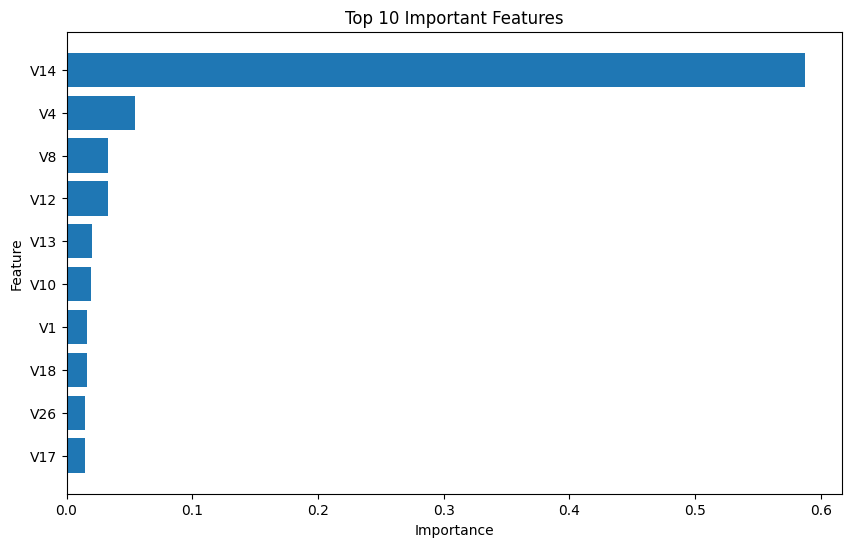

In [ ]:
plt.figure(figsize=(10,6))
plt.barh(feature_importance['Feature'][:10][::-1], feature_importance['Importance'][:10][::-1])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Important Features")
plt.show()

#### **Feature Importance Analysis**

The feature importance results indicate that **V14 is the most influential feature**, contributing the majority of the model’s predictive power.
Compared to V14, all other features such as V4, V8, V12, and V10 have significantly lower importance, suggesting that their contribution to fraud detection is relatively minor.

This implies that the model primarily relies on **V14 to distinguish between fraudulent and legitimate transactions**, while other features provide only incremental support.
Such behavior is expected in this dataset, as the features are PCA-transformed components, and certain components can capture strong underlying fraud patterns.

### **Save Model + Build Prediction Pipeline**

In [ ]:
import joblib

imputer = X_train.median()
joblib.dump(imputer, "imputer.pkl")
joblib.dump(xgb_smote, "model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(0.82, "threshold.pkl")

['threshold.pkl']

In [ ]:
model = joblib.load("model.pkl")
scaler = joblib.load("scaler.pkl")
threshold = joblib.load("threshold.pkl")

def predict_transaction(input_data):
    """
    input_data: list or array of features (V1–V28 + Amount)
    """

    data = np.array(input_data).reshape(1, -1)
    data[0, -1] = scaler.transform([[data[0, -1]]])[0][0]

    # Predict probability
    prob = model.predict_proba(data)[0][1]
    prediction = 1 if prob >= threshold else 0

    return {
        "fraud_probability": float(prob),
        "prediction": "Fraud" if prediction == 1 else "Normal"
    }

In [ ]:
sample = X_test.iloc[0]
result = predict_transaction(sample)
print(result)

{'fraud_probability': 1.517851615062682e-05, 'prediction': 'Normal'}


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
sample = X_test[Y_test==1].iloc[0]
result = predict_transaction(sample)
print(result)

{'fraud_probability': 0.9999340772628784, 'prediction': 'Fraud'}


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


#### **Model Saving and Prediction Pipeline**

The final trained XGBoost model, along with preprocessing components such as the scaler and optimized classification threshold, were saved using the `joblib` library.

A prediction pipeline was implemented to process new transaction data, apply necessary preprocessing steps, and generate fraud predictions based on the trained model.

This setup enables the model to be deployed in real-world applications where it can evaluate new transactions in real time.